# 16. 초기 탐지 결과 통합

09~15번 실험의 in-domain, unseen 생성기, MP3 결과를 모아 모델별 오류를 비교한다. 여기서는 모델을 새로 학습하지 않는다. 22~27번의 후속 실험 결과와는 실행 시점을 구분한다. 이 노트북의 RQ1과 그림은 SVM·CNN 비교에 초점을 맞췄다. 초기 Logistic Regression의 학습·평가 결과는 09번 노트북에 있다.

## 1. 라이브러리 / 경로 설정

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

FINAL_DIR = PROJECT_ROOT / "results/final_analysis"
FIG_DIR = FINAL_DIR / "figures"

FINAL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    # 09
    "baseline_metrics": PROJECT_ROOT / "results/baseline/baseline_metrics.csv",
    "svm_track_pred": PROJECT_ROOT / "results/baseline/test_track_predictions.csv",
    # 10
    "svm_generator": PROJECT_ROOT
    / "results/baseline/subgroup_analysis/rbf_svm_track_generator_metrics.csv",
    # 11
    "svm_unseen": PROJECT_ROOT
    / "results/unseen_generator/rbf_svm_track_unseen_summary.csv",
    # 12
    "svm_mp3": PROJECT_ROOT
    / "results/mp3_robustness/rbf_svm_track_robustness_summary.csv",
    "svm_generator_mp3": PROJECT_ROOT
    / "results/mp3_robustness/generator_compression_metrics.csv",
    # 13
    "cnn_metrics": PROJECT_ROOT / "results/cnn/cnn_metrics.csv",
    "cnn_track_pred": PROJECT_ROOT / "results/cnn/test_track_predictions.csv",
    # 14
    "cnn_unseen": PROJECT_ROOT
    / "results/cnn_unseen_generator/cnn_track_unseen_summary.csv",
    "cnn_in_vs_unseen": PROJECT_ROOT
    / "results/cnn_unseen_generator/cnn_in_domain_vs_unseen.csv",
    # 15
    "cnn_mp3": PROJECT_ROOT
    / "results/cnn_mp3_robustness/cnn_mp3_robustness_metrics.csv",
    "cnn_generator_mp3": PROJECT_ROOT
    / "results/cnn_mp3_robustness/cnn_generator_compression_metrics.csv",
}

print("Final output:", FINAL_DIR)

Final output: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/final_analysis


## 2. 결과 파일 QC

In [2]:
# 결과 파일 QC
file_qc = pd.DataFrame(
    [
        {
            "name": name,
            "exists": path.exists(),
            "path": str(path),
        }
        for name, path in PATHS.items()
    ]
)

display(file_qc)

missing = file_qc.loc[~file_qc["exists"], "name"].tolist()

if missing:
    raise FileNotFoundError(
        "다음 결과 파일이 없습니다: "
        + ", ".join(missing)
        + "\n해당 이전 노트북의 결과 저장 셀을 먼저 실행하세요."
    )

print("Result File QC PASS: True")

,name,exists,path
0,baseline_metrics,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
1,svm_track_pred,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
2,svm_generator,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
3,svm_unseen,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
4,svm_mp3,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
5,svm_generator_mp3,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
6,cnn_metrics,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
7,cnn_track_pred,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
8,cnn_unseen,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...
9,cnn_in_vs_unseen,True,/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project...


Result File QC PASS: True


## 3. 결과 파일 로드

In [3]:
baseline = pd.read_csv(PATHS["baseline_metrics"])
svm_unseen = pd.read_csv(PATHS["svm_unseen"])
svm_mp3 = pd.read_csv(PATHS["svm_mp3"])
svm_gen_mp3 = pd.read_csv(PATHS["svm_generator_mp3"])

cnn_metrics = pd.read_csv(PATHS["cnn_metrics"])
cnn_unseen = pd.read_csv(PATHS["cnn_unseen"])
cnn_in_vs_unseen = pd.read_csv(PATHS["cnn_in_vs_unseen"])
cnn_mp3_all = pd.read_csv(PATHS["cnn_mp3"])
cnn_gen_mp3 = pd.read_csv(PATHS["cnn_generator_mp3"])

svm_track_pred = pd.read_csv(PATHS["svm_track_pred"])
cnn_track_pred = pd.read_csv(PATHS["cnn_track_pred"])

print("Loaded all result files.")

Loaded all result files.


## 4. 15번 Full-decode 결과 저장 여부 확인

Full-decode 재검증에서 확인한 CNN Track ROC-AUC는 대략:

- Original: `0.9772`
- MP3 128k: `0.8954`
- MP3 64k: `0.8256`

현재 저장 CSV는 Full-decode 재평가 결과인 Original `0.9772`, MP3 128k `0.8954`, MP3 64k `0.8256`을 반영한다.

In [4]:
# 15번 Full-decode 결과 저장 여부 확인
cnn_mp3_track_check = cnn_mp3_all[cnn_mp3_all["level"] == "track"][
    ["condition", "roc_auc"]
].sort_values("condition")

display(cnn_mp3_track_check.round(4))

lookup = dict(
    zip(
        cnn_mp3_track_check["condition"],
        cnn_mp3_track_check["roc_auc"],
    )
)

full_decode_expected = {
    "original": 0.9772,
    "mp3_128": 0.8954,
    "mp3_64": 0.8256,
}

max_diff = max(abs(float(lookup[k]) - v) for k, v in full_decode_expected.items())

print("Max difference vs full-decode reference:", round(max_diff, 6))

if max_diff <= 0.002:
    print("Full-decode consistency PASS: True")
else:
    print(
        "WARNING: 15번 Full-decode 재평가 후 "
        "결과 저장 셀을 다시 실행하는 것을 권장합니다."
    )

,condition,roc_auc
3,mp3_128,0.8954
5,mp3_64,0.8256
1,original,0.9772


Max difference vs full-decode reference: 4.1e-05
Full-decode consistency PASS: True


## 5. RQ1 — In-domain Test: RBF-SVM vs Log-Mel CNN

In [5]:
svm_test = baseline[
    # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
    (baseline["model"] == "RBF-SVM") & (baseline["split"] == "test")
].copy()

cnn_test = cnn_metrics[cnn_metrics["split"] == "test"].copy()

rq1 = pd.concat(
    [
        svm_test[
            [
                "model",
                "level",
                "roc_auc",
                "eer",
                "balanced_accuracy",
                "macro_f1",
                "real_fpr",
                "fake_miss_rate",
            ]
        ],
        cnn_test[
            [
                "model",
                "level",
                "roc_auc",
                "eer",
                "balanced_accuracy",
                "macro_f1",
                "real_fpr",
                "fake_miss_rate",
            ]
        ],
    ],
    ignore_index=True,
)

rq1 = rq1.sort_values(["level", "model"]).reset_index(drop=True)

display(rq1.round(4))

,model,level,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate
0,LogMelCNN,segment,0.9520,0.1349,0.8791,0.7795,0.1556,0.0863
1,RBF-SVM,segment,0.9262,0.1475,0.8463,0.7115,0.1704,0.1371
2,LogMelCNN,track,0.9772,0.1042,0.9111,0.8535,0.1333,0.0445
3,RBF-SVM,track,0.9644,0.1395,0.8696,0.7502,0.1556,0.1053


## 6. Segment → Track aggregation 효과

In [6]:
# Segment → Track aggregation 효과
aggregation_rows = []

for model_name in ["RBF-SVM", "LogMelCNN"]:
    temp = rq1[rq1["model"] == model_name].set_index("level")

    segment = temp.loc["segment"]
    track = temp.loc["track"]

    aggregation_rows.append(
        {
            "model": model_name,
            "segment_auc": segment["roc_auc"],
            "track_auc": track["roc_auc"],
            "auc_gain": track["roc_auc"] - segment["roc_auc"],
            "segment_eer": segment["eer"],
            "track_eer": track["eer"],
            "eer_reduction": segment["eer"] - track["eer"],
            "segment_macro_f1": segment["macro_f1"],
            "track_macro_f1": track["macro_f1"],
            "macro_f1_gain": track["macro_f1"] - segment["macro_f1"],
        }
    )

aggregation = pd.DataFrame(aggregation_rows)

display(aggregation.round(4))

,model,segment_auc,track_auc,auc_gain,segment_eer,track_eer,eer_reduction,segment_macro_f1,track_macro_f1,macro_f1_gain
0,RBF-SVM,0.9262,0.9644,0.0383,0.1475,0.1395,0.0079,0.7115,0.7502,0.0387
1,LogMelCNN,0.9520,0.9772,0.0252,0.1349,0.1042,0.0307,0.7795,0.8535,0.0741


## 7. RQ1 핵심 차이 — CNN minus SVM

In [7]:
# RQ1 핵심 차이 — CNN minus SVM
svm_track = rq1[(rq1["model"] == "RBF-SVM") & (rq1["level"] == "track")].iloc[0]

cnn_track = rq1[(rq1["model"] == "LogMelCNN") & (rq1["level"] == "track")].iloc[0]

rq1_delta = pd.DataFrame(
    [
        {
            "comparison": "CNN - RBF-SVM (Track Test)",
            "roc_auc_change": cnn_track["roc_auc"] - svm_track["roc_auc"],
            "eer_change": cnn_track["eer"] - svm_track["eer"],
            "balanced_accuracy_change": cnn_track["balanced_accuracy"]
            - svm_track["balanced_accuracy"],
            "macro_f1_change": cnn_track["macro_f1"] - svm_track["macro_f1"],
            "real_fpr_change": cnn_track["real_fpr"] - svm_track["real_fpr"],
            "fake_miss_change": cnn_track["fake_miss_rate"]
            - svm_track["fake_miss_rate"],
        }
    ]
)

display(rq1_delta.round(4))

,comparison,roc_auc_change,eer_change,balanced_accuracy_change,macro_f1_change,real_fpr_change,fake_miss_change
0,CNN - RBF-SVM (Track Test),0.0128,-0.0354,0.0415,0.1033,-0.0222,-0.0607


## 8. RQ2 — Unseen Generator: SVM vs CNN

In [8]:
# RQ2 — Unseen Generator: SVM vs CNN
svm_unseen_core = svm_unseen[
    [
        "holdout_generator",
        "n_real",
        "n_fake",
        "roc_auc",
        "eer",
        "balanced_accuracy",
        "macro_f1",
        "real_fpr",
        "fake_miss_rate",
    ]
].copy()
svm_unseen_core["model"] = "RBF-SVM"

cnn_unseen_core = cnn_unseen[
    [
        "holdout_generator",
        "n_real",
        "n_fake",
        "roc_auc",
        "eer",
        "balanced_accuracy",
        "macro_f1",
        "real_fpr",
        "fake_miss_rate",
    ]
].copy()
cnn_unseen_core["model"] = "LogMelCNN"

rq2 = pd.concat(
    [svm_unseen_core, cnn_unseen_core],
    ignore_index=True,
)

rq2 = rq2.sort_values(["holdout_generator", "model"]).reset_index(drop=True)

display(
    rq2[
        [
            "holdout_generator",
            "model",
            "n_real",
            "n_fake",
            "roc_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
        ]
    ].round(4)
)

,holdout_generator,model,n_real,n_fake,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate
0,musicgen,LogMelCNN,45,45,0.8681,0.2667,0.7333,0.7285,0.1333,0.4000
1,musicgen,RBF-SVM,45,45,0.6123,0.4000,0.5222,0.4669,0.1556,0.8000
2,udio,LogMelCNN,45,48,0.8227,0.2146,0.7653,0.7632,0.1778,0.2917
3,udio,RBF-SVM,45,48,0.8542,0.2368,0.7361,0.7266,0.1111,0.4167


## 9. RQ2 — 모델별 Unseen AUC 비교

In [9]:
# RQ2 — 모델별 Unseen AUC 비교
rq2_auc = rq2.pivot(
    index="holdout_generator",
    columns="model",
    values="roc_auc",
).reset_index()

rq2_auc["CNN_minus_SVM_AUC"] = rq2_auc["LogMelCNN"] - rq2_auc["RBF-SVM"]

display(rq2_auc.round(4))

model,holdout_generator,LogMelCNN,RBF-SVM,CNN_minus_SVM_AUC
0,musicgen,0.8681,0.6123,0.2558
1,udio,0.8227,0.8542,-0.0315


## 10. CNN In-domain → Unseen 성능 하락

In [10]:
# CNN In-domain → Unseen 성능 하락
cnn_shift = cnn_in_vs_unseen.copy()

wanted = [
    "holdout_generator",
    "in_domain_roc_auc",
    "roc_auc",
    "roc_auc_drop",
    "in_domain_eer",
    "eer",
    "eer_increase",
    "in_domain_fake_miss_rate",
    "fake_miss_rate",
    "fake_miss_increase",
]

display(cnn_shift[wanted].round(4))

,holdout_generator,in_domain_roc_auc,roc_auc,roc_auc_drop,in_domain_eer,eer,eer_increase,in_domain_fake_miss_rate,fake_miss_rate,fake_miss_increase
0,musicgen,0.9748,0.8681,0.1067,0.0778,0.2667,0.1889,0.0444,0.4000,0.3556
1,udio,0.9671,0.8227,0.1444,0.0861,0.2146,0.1285,0.0417,0.2917,0.2500


## 11. RQ3 — MP3 Robustness: Track-level SVM vs CNN

In [11]:
# RQ3 — MP3 Robustness: Track-level SVM vs CNN
svm_mp3_core = svm_mp3[
    [
        "condition",
        "roc_auc",
        "eer",
        "balanced_accuracy",
        "macro_f1",
        "real_fpr",
        "fake_miss_rate",
    ]
].copy()
svm_mp3_core["model"] = "RBF-SVM"

cnn_mp3_core = cnn_mp3_all[cnn_mp3_all["level"] == "track"][
    [
        "condition",
        "roc_auc",
        "eer",
        "balanced_accuracy",
        "macro_f1",
        "real_fpr",
        "fake_miss_rate",
    ]
].copy()
cnn_mp3_core["model"] = "LogMelCNN"

rq3 = pd.concat(
    [svm_mp3_core, cnn_mp3_core],
    ignore_index=True,
)

cond_order = pd.CategoricalDtype(
    ["original", "mp3_128", "mp3_64"],
    ordered=True,
)

rq3["condition"] = rq3["condition"].astype(cond_order)
rq3 = rq3.sort_values(["model", "condition"]).reset_index(drop=True)

display(
    rq3[
        [
            "model",
            "condition",
            "roc_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
        ]
    ].round(4)
)

,model,condition,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate
0,LogMelCNN,original,0.9772,0.1042,0.9111,0.8535,0.1333,0.0445
1,LogMelCNN,mp3_128,0.8954,0.1830,0.7626,0.7765,0.4444,0.0304
2,LogMelCNN,mp3_64,0.8256,0.2892,0.7179,0.5430,0.2444,0.3198
3,RBF-SVM,original,0.9644,0.1395,0.8696,0.7502,0.1556,0.1053
4,RBF-SVM,mp3_128,0.9536,0.1325,0.8676,0.7692,0.1778,0.0870
5,RBF-SVM,mp3_64,0.9062,0.1688,0.8494,0.7437,0.2000,0.1012


## 12. RQ3 — Original 대비 압축 성능 변화

In [12]:
# RQ3 — Original 대비 압축 성능 변화
compression_change_rows = []

for model_name in ["RBF-SVM", "LogMelCNN"]:
    temp = rq3[rq3["model"] == model_name].set_index("condition")

    original = temp.loc["original"]

    for condition in ["original", "mp3_128", "mp3_64"]:
        r = temp.loc[condition]

        compression_change_rows.append(
            {
                "model": model_name,
                "condition": condition,
                "roc_auc_drop": original["roc_auc"] - r["roc_auc"],
                "eer_increase": r["eer"] - original["eer"],
                "balanced_accuracy_drop": original["balanced_accuracy"]
                - r["balanced_accuracy"],
                "real_fpr_change": r["real_fpr"] - original["real_fpr"],
                "fake_miss_change": r["fake_miss_rate"] - original["fake_miss_rate"],
            }
        )

compression_change = pd.DataFrame(compression_change_rows)

display(compression_change.round(4))

,model,condition,roc_auc_drop,eer_increase,balanced_accuracy_drop,real_fpr_change,fake_miss_change
0,RBF-SVM,original,0.0000,0.0000,0.0000,0.0000,0.0000
1,RBF-SVM,mp3_128,0.0108,-0.0071,0.0020,0.0222,-0.0182
2,RBF-SVM,mp3_64,0.0583,0.0293,0.0202,0.0444,-0.0040
3,LogMelCNN,original,0.0000,0.0000,0.0000,0.0000,0.0000
4,LogMelCNN,mp3_128,0.0818,0.0789,0.1485,0.3111,-0.0142
5,LogMelCNN,mp3_64,0.1516,0.1850,0.1932,0.1111,0.2753


## 13. Generator별 MP3 64k 취약성 — SVM vs CNN

In [13]:
# Generator별 MP3 64k 취약성 — SVM vs CNN
svm_gen_auc = svm_gen_mp3.pivot(
    index="generator",
    columns="condition",
    values="roc_auc",
)

cnn_gen_auc = cnn_gen_mp3.pivot(
    index="generator",
    columns="condition",
    values="roc_auc",
)

svm_gen_auc["svm_drop_64"] = svm_gen_auc["original"] - svm_gen_auc["mp3_64"]

cnn_gen_auc["cnn_drop_64"] = cnn_gen_auc["original"] - cnn_gen_auc["mp3_64"]

generator_64_compare = pd.DataFrame(
    {
        "svm_original": svm_gen_auc["original"],
        "svm_mp3_64": svm_gen_auc["mp3_64"],
        "svm_drop_64": svm_gen_auc["svm_drop_64"],
        "cnn_original": cnn_gen_auc["original"],
        "cnn_mp3_64": cnn_gen_auc["mp3_64"],
        "cnn_drop_64": cnn_gen_auc["cnn_drop_64"],
    }
).reset_index()

generator_64_compare["cnn_minus_svm_drop"] = (
    generator_64_compare["cnn_drop_64"] - generator_64_compare["svm_drop_64"]
)

display(generator_64_compare.sort_values("cnn_drop_64", ascending=False).round(4))

,generator,svm_original,svm_mp3_64,svm_drop_64,cnn_original,cnn_mp3_64,cnn_drop_64,cnn_minus_svm_drop
3,diffrhythm,0.9863,0.8161,0.1702,0.9901,0.6861,0.3040,0.1338
10,suno,0.9722,0.8764,0.0958,0.9569,0.6935,0.2634,0.1676
5,mubert,0.9528,0.9111,0.0417,0.9241,0.6648,0.2593,0.2176
2,brev,0.9694,0.8796,0.0898,0.9736,0.7639,0.2097,0.1199
11,udio,0.9014,0.8917,0.0097,0.9671,0.7694,0.1977,0.1880
4,elevenlabs,0.8968,0.8227,0.0741,0.9606,0.7917,0.1690,0.0949
7,producer,0.9591,0.9058,0.0533,0.9822,0.8187,0.1636,0.1102
0,acestep,0.9886,0.9304,0.0583,0.9881,0.8504,0.1378,0.0795
9,stableaudio,0.9538,0.9188,0.0350,0.9983,0.9179,0.0803,0.0453
6,musicgen,0.9951,0.9802,0.0148,0.9748,0.9437,0.0311,0.0163


## 14. CNN에서 가장 codec-sensitive / codec-stable generator

In [14]:
# CNN에서 가장 codec-sensitive / codec-stable generator
cnn_sensitive = generator_64_compare.sort_values("cnn_drop_64", ascending=False).head(5)

cnn_stable = generator_64_compare.sort_values("cnn_drop_64", ascending=True).head(5)

print("CNN — Largest 64k AUC drops")
display(
    cnn_sensitive[
        [
            "generator",
            "cnn_original",
            "cnn_mp3_64",
            "cnn_drop_64",
        ]
    ].round(4)
)

print("\nCNN — Most stable under 64k")
display(
    cnn_stable[
        [
            "generator",
            "cnn_original",
            "cnn_mp3_64",
            "cnn_drop_64",
        ]
    ].round(4)
)

CNN — Largest 64k AUC drops


,generator,cnn_original,cnn_mp3_64,cnn_drop_64
3,diffrhythm,0.9901,0.6861,0.3040
10,suno,0.9569,0.6935,0.2634
5,mubert,0.9241,0.6648,0.2593
2,brev,0.9736,0.7639,0.2097
11,udio,0.9671,0.7694,0.1977



CNN — Most stable under 64k


,generator,cnn_original,cnn_mp3_64,cnn_drop_64
8,songgen,1.0000,0.9980,0.0020
1,audioldm,1.0000,0.9956,0.0044
6,musicgen,0.9748,0.9437,0.0311
9,stableaudio,0.9983,0.9179,0.0803
0,acestep,0.9881,0.8504,0.1378


## 15. 오류 유형 변화 — REAL FPR vs FAKE Miss

In [15]:
# 오류 유형 변화 — REAL FPR vs FAKE Miss
error_shift = rq3[
    [
        "model",
        "condition",
        "real_fpr",
        "fake_miss_rate",
    ]
].copy()

display(error_shift.round(4))

,model,condition,real_fpr,fake_miss_rate
0,LogMelCNN,original,0.1333,0.0445
1,LogMelCNN,mp3_128,0.4444,0.0304
2,LogMelCNN,mp3_64,0.2444,0.3198
3,RBF-SVM,original,0.1556,0.1053
4,RBF-SVM,mp3_128,0.1778,0.0870
5,RBF-SVM,mp3_64,0.2000,0.1012


## 16. 대표 오류 사례 — In-domain Test

고정 Validation threshold 기준으로:

- `REAL → FAKE` = false positive
- `FAKE → REAL` = false negative / FAKE miss

점수가 threshold에서 멀수록 모델이 더 자신 있게 틀린 사례로 볼 수 있다.

In [16]:
# SVM
svm_fp = (
    svm_track_pred[
        (svm_track_pred["label_id"] == 0) & (svm_track_pred["svm_pred"] == 1)
    ]
    .sort_values("svm_score", ascending=False)
    .head(10)
)

svm_fn = (
    svm_track_pred[
        (svm_track_pred["label_id"] == 1) & (svm_track_pred["svm_pred"] == 0)
    ]
    .sort_values("svm_score", ascending=True)
    .head(10)
)

# CNN
cnn_fp = (
    cnn_track_pred[
        (cnn_track_pred["label_id"] == 0) & (cnn_track_pred["cnn_pred"] == 1)
    ]
    .sort_values("cnn_score", ascending=False)
    .head(10)
)

cnn_fn = (
    cnn_track_pred[
        (cnn_track_pred["label_id"] == 1) & (cnn_track_pred["cnn_pred"] == 0)
    ]
    .sort_values("cnn_score", ascending=True)
    .head(10)
)

error_cols_svm = [
    "track_sample_id",
    "original_audio",
    "label",
    "genre",
    "generator",
    "svm_score",
]

error_cols_cnn = [
    "track_sample_id",
    "original_audio",
    "label",
    "genre",
    "generator",
    "cnn_score",
]

print("RBF-SVM — confident REAL false positives")
display(svm_fp[error_cols_svm])

print("\nRBF-SVM — confident FAKE misses")
display(svm_fn[error_cols_svm])

print("\nLogMelCNN — confident REAL false positives")
display(cnn_fp[error_cols_cnn])

print("\nLogMelCNN — confident FAKE misses")
display(cnn_fn[error_cols_cnn])

RBF-SVM — confident REAL false positives


,track_sample_id,original_audio,label,genre,generator,svm_score
26,sample_00178,Realize Me - Jim Rooster,REAL,Electronic,NaN,0.956254
3,sample_00021,Attention - Pete Prodoehl,REAL,Rock,NaN,0.948694
17,sample_00123,Let's Start Out Slow - RoccoW,REAL,Electronic,NaN,0.942165
19,sample_00139,Moja Krypta - AmortE,REAL,Rock,NaN,0.912916
28,sample_00195,Set Fire to Creation - Nihilore,REAL,Electronic,NaN,0.912569
6,sample_00049,Different Day - First,REAL,Pop,NaN,0.911645
9,sample_00079,Fuckaboing - RoccoW,REAL,Electronic,NaN,0.887196



RBF-SVM — confident FAKE misses


,track_sample_id,original_audio,label,genre,generator,svm_score
389,sample_02494,"Hungry - Oh Yeah, the Future",FAKE,Pop,udio,0.385091
484,sample_03089,Terve Teille - Чокнутый Пропеллер,FAKE,Rock,elevenlabs,0.437997
492,sample_03135,Who Loves You Dear - Mink Lungs,FAKE,Rock,elevenlabs,0.505697
395,sample_02538,She Works / Tepid Waters - Bird Names,FAKE,Pop,udio,0.520764
412,sample_02643,Stuttgart - Portrayal,FAKE,Rock,udio,0.619430
336,sample_02165,Ugh! Humans Can Join - Mystery Mammal,FAKE,Electronic,suno,0.645584
415,sample_02646,Terve Teille - Чокнутый Пропеллер,FAKE,Rock,udio,0.655982
401,sample_02576,Attention - Pete Prodoehl,FAKE,Rock,udio,0.667281
490,sample_03133,Where Is Everything - The Moi Non Plus,FAKE,Rock,elevenlabs,0.694506
383,sample_02444,Resistentialism - Nihilore,FAKE,Electronic,udio,0.699699



LogMelCNN — confident REAL false positives


,track_sample_id,original_audio,label,genre,generator,cnn_score
17,sample_00123,Let's Start Out Slow - RoccoW,REAL,Electronic,NaN,0.378646
3,sample_00021,Attention - Pete Prodoehl,REAL,Rock,NaN,0.377981
10,sample_00087,"Head of Ancante, Talking Tree - Ak'chamel, The...",REAL,Rock,NaN,0.248598
26,sample_00178,Realize Me - Jim Rooster,REAL,Electronic,NaN,0.234519
1,sample_00004,3 am West End - statusq,REAL,Electronic,NaN,0.134750
5,sample_00045,Dance Harder - Three Chain Links,REAL,Electronic,NaN,0.106391



LogMelCNN — confident FAKE misses


,track_sample_id,original_audio,label,genre,generator,cnn_score
326,sample_02101,Fuckaboing - RoccoW,FAKE,Electronic,suno,0.004108
237,sample_01531,Troubles I've seen - Malaventura,FAKE,Pop,mubert,0.005972
394,sample_02537,She Works / Tepid Waters - Bird Names,FAKE,Pop,udio,0.008365
453,sample_02932,Fuckaboing - RoccoW,FAKE,Electronic,elevenlabs,0.008623
251,sample_01623,"Head of Ancante, Talking Tree - Ak'chamel, The...",FAKE,Rock,mubert,0.010480
490,sample_03133,Where Is Everything - The Moi Non Plus,FAKE,Rock,elevenlabs,0.026322
395,sample_02538,She Works / Tepid Waters - Bird Names,FAKE,Pop,udio,0.029372
253,sample_01626,LIQUID SKULLS - voyageurs,FAKE,Rock,mubert,0.029676
511,sample_03301,Love Dream - The Zombie Dandies,FAKE,Rock,musicgen,0.034392
52,sample_00353,El Burrito - Malaventura,FAKE,Pop,acestep,0.034840


## 17. Figure 1 — In-domain Track 성능

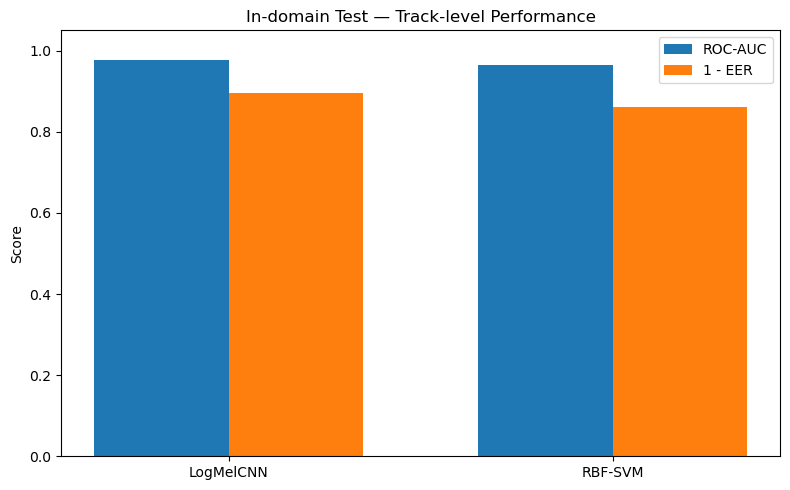

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/final_analysis/figures/01_in_domain_track_performance.png


In [17]:
track_plot = rq1[rq1["level"] == "track"].copy()

x = np.arange(len(track_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    track_plot["roc_auc"],
    width,
    label="ROC-AUC",
)

ax.bar(
    x + width / 2,
    1 - track_plot["eer"],
    width,
    label="1 - EER",
)

ax.set_xticks(x)
ax.set_xticklabels(track_plot["model"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("In-domain Test — Track-level Performance")
ax.legend()

fig.tight_layout()

figure_path = FIG_DIR / "01_in_domain_track_performance.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## 18. Figure 2 — Unseen Generator ROC-AUC

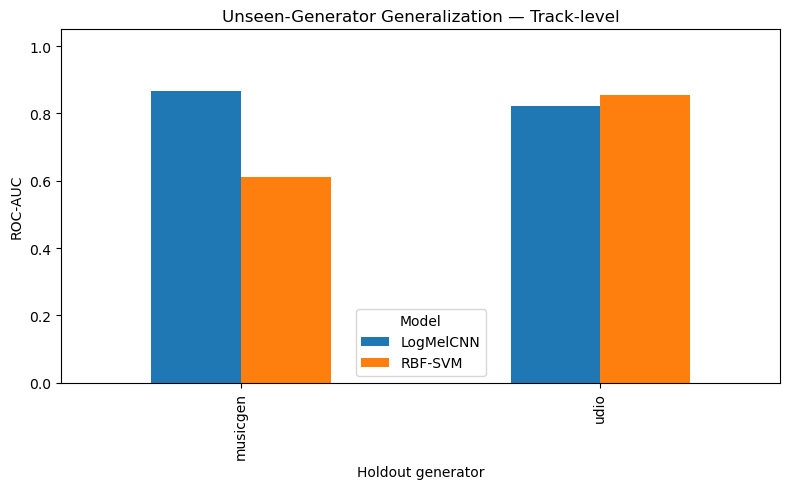

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/final_analysis/figures/02_unseen_generator_auc.png


In [18]:
unseen_plot = rq2[
    [
        "holdout_generator",
        "model",
        "roc_auc",
    ]
].pivot(
    index="holdout_generator",
    columns="model",
    values="roc_auc",
)

ax = unseen_plot.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("Holdout generator")
ax.set_title("Unseen-Generator Generalization — Track-level")
ax.legend(title="Model")

fig = ax.get_figure()
fig.tight_layout()

figure_path = FIG_DIR / "02_unseen_generator_auc.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## 19. Figure 3 — MP3 Compression Robustness

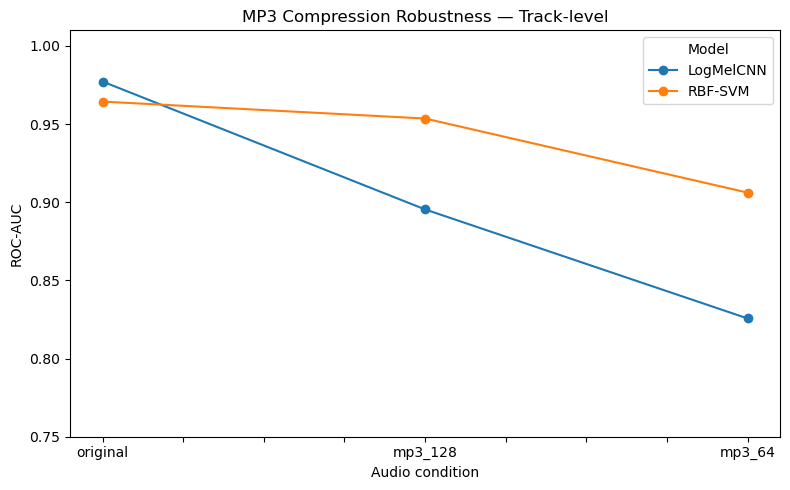

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/final_analysis/figures/03_mp3_robustness_auc.png


In [19]:
compression_plot = (
    rq3[
        [
            "model",
            "condition",
            "roc_auc",
        ]
    ]
    .pivot(
        index="condition",
        columns="model",
        values="roc_auc",
    )
    .reindex(["original", "mp3_128", "mp3_64"])
)

ax = compression_plot.plot(
    marker="o",
    figsize=(8, 5),
)

ax.set_ylim(0.75, 1.01)
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("Audio condition")
ax.set_title("MP3 Compression Robustness — Track-level")
ax.legend(title="Model")

fig = ax.get_figure()
fig.tight_layout()

figure_path = FIG_DIR / "03_mp3_robustness_auc.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## 20. Figure 4 — CNN Generator별 64k AUC 감소

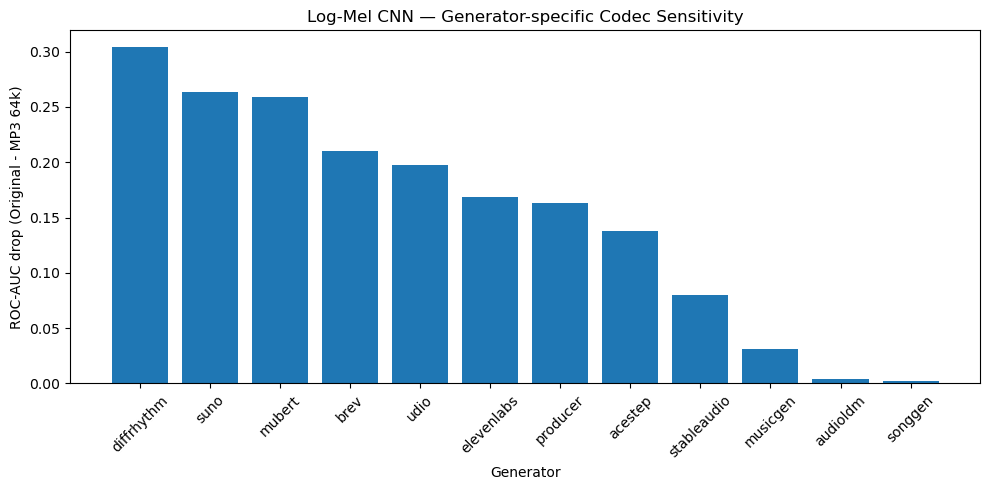

Saved: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/final_analysis/figures/04_cnn_generator_64k_auc_drop.png


In [20]:
temp = generator_64_compare[
    [
        "generator",
        "cnn_drop_64",
    ]
].sort_values("cnn_drop_64", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    temp["generator"],
    temp["cnn_drop_64"],
)

ax.set_ylabel("ROC-AUC drop (Original - MP3 64k)")
ax.set_xlabel("Generator")
ax.set_title("Log-Mel CNN — Generator-specific Codec Sensitivity")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()

figure_path = FIG_DIR / "04_cnn_generator_64k_auc_drop.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## 21. 연구 질문별 최종 요약표

In [21]:
# 핵심 숫자
svm_track_auc = float(svm_track["roc_auc"])
cnn_track_auc = float(cnn_track["roc_auc"])

musicgen_svm = float(
    rq2[(rq2["holdout_generator"] == "musicgen") & (rq2["model"] == "RBF-SVM")][
        "roc_auc"
    ].iloc[0]
)

musicgen_cnn = float(
    rq2[(rq2["holdout_generator"] == "musicgen") & (rq2["model"] == "LogMelCNN")][
        "roc_auc"
    ].iloc[0]
)

udio_svm = float(
    rq2[(rq2["holdout_generator"] == "udio") & (rq2["model"] == "RBF-SVM")][
        "roc_auc"
    ].iloc[0]
)

udio_cnn = float(
    rq2[(rq2["holdout_generator"] == "udio") & (rq2["model"] == "LogMelCNN")][
        "roc_auc"
    ].iloc[0]
)

svm_64 = float(
    rq3[(rq3["model"] == "RBF-SVM") & (rq3["condition"] == "mp3_64")]["roc_auc"].iloc[0]
)

cnn_64 = float(
    rq3[(rq3["model"] == "LogMelCNN") & (rq3["condition"] == "mp3_64")]["roc_auc"].iloc[
        0
    ]
)

final_summary = pd.DataFrame(
    [
        {
            "research_question": "RQ1 In-domain",
            "key_result": f"Track AUC: SVM {svm_track_auc:.4f} vs CNN {cnn_track_auc:.4f}",
            "interpretation": "Clean/in-domain에서는 Log-Mel CNN이 더 높은 판별 성능을 보임.",
        },
        {
            "research_question": "RQ1 Track aggregation",
            "key_result": "두 모델 모두 Segment보다 Track aggregation에서 AUC/EER 개선",
            "interpretation": "여러 10초 구간의 점수 평균이 곡 단위 판단을 안정화함.",
        },
        {
            "research_question": "RQ2 MusicGen unseen",
            "key_result": f"AUC: SVM {musicgen_svm:.4f} vs CNN {musicgen_cnn:.4f}",
            "interpretation": "CNN이 MusicGen generator shift에서 SVM보다 훨씬 높은 일반화 성능.",
        },
        {
            "research_question": "RQ2 Udio unseen",
            "key_result": f"AUC: SVM {udio_svm:.4f} vs CNN {udio_cnn:.4f}",
            "interpretation": "Udio에서는 AUC 기준 SVM이 약간 높아 모델 우위가 generator별로 달라짐.",
        },
        {
            "research_question": "RQ3 MP3 64k",
            "key_result": f"AUC: SVM {svm_64:.4f} vs CNN {cnn_64:.4f}",
            "interpretation": "CNN은 clean 성능은 높지만 codec shift에는 SVM보다 더 민감함.",
        },
        {
            "research_question": "Overall",
            "key_result": "High in-domain performance != distribution-shift robustness",
            "interpretation": "미지 생성기와 codec 압축을 별도 robustness 축으로 평가해야 함.",
        },
    ]
)

display(final_summary)

,research_question,key_result,interpretation
0,RQ1 In-domain,Track AUC: SVM 0.9644 vs CNN 0.9772,Clean/in-domain에서는 Log-Mel CNN이 더 높은 판별 성능을 보임.
1,RQ1 Track aggregation,두 모델 모두 Segment보다 Track aggregation에서 AUC/EER 개선,여러 10초 구간의 점수 평균이 곡 단위 판단을 안정화함.
2,RQ2 MusicGen unseen,AUC: SVM 0.6123 vs CNN 0.8681,CNN이 MusicGen generator shift에서 SVM보다 훨씬 높은 일반...
3,RQ2 Udio unseen,AUC: SVM 0.8542 vs CNN 0.8227,Udio에서는 AUC 기준 SVM이 약간 높아 모델 우위가 generator별로 달라짐.
4,RQ3 MP3 64k,AUC: SVM 0.9062 vs CNN 0.8256,CNN은 clean 성능은 높지만 codec shift에는 SVM보다 더 민감함.
5,Overall,High in-domain performance != distribution-shi...,미지 생성기와 codec 압축을 별도 robustness 축으로 평가해야 함.


## 22. 결과 자동 저장

In [22]:
rq1.to_csv(
    FINAL_DIR / "01_in_domain_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

aggregation.to_csv(
    FINAL_DIR / "02_segment_track_aggregation.csv",
    index=False,
    encoding="utf-8-sig",
)

rq2.to_csv(
    FINAL_DIR / "03_unseen_generator_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

cnn_shift.to_csv(
    FINAL_DIR / "04_cnn_in_domain_vs_unseen.csv",
    index=False,
    encoding="utf-8-sig",
)

rq3.to_csv(
    FINAL_DIR / "05_mp3_robustness_model_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

compression_change.to_csv(
    FINAL_DIR / "06_mp3_robustness_changes.csv",
    index=False,
    encoding="utf-8-sig",
)

generator_64_compare.to_csv(
    FINAL_DIR / "07_generator_64k_robustness.csv",
    index=False,
    encoding="utf-8-sig",
)

final_summary.to_csv(
    FINAL_DIR / "08_research_question_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

svm_fp.to_csv(
    FINAL_DIR / "09_svm_confident_real_false_positives.csv",
    index=False,
    encoding="utf-8-sig",
)

svm_fn.to_csv(
    FINAL_DIR / "10_svm_confident_fake_misses.csv",
    index=False,
    encoding="utf-8-sig",
)

cnn_fp.to_csv(
    FINAL_DIR / "11_cnn_confident_real_false_positives.csv",
    index=False,
    encoding="utf-8-sig",
)

cnn_fn.to_csv(
    FINAL_DIR / "12_cnn_confident_fake_misses.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved final analysis files to:", FINAL_DIR)

Saved final analysis files to: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/final_analysis


## 23. 최종 QC

In [23]:
# 최종 QC
qc = pd.DataFrame(
    [
        {
            "check": "all_input_files_exist",
            "value": bool(file_qc["exists"].all()),
        },
        {
            "check": "rq1_models",
            "value": int(rq1["model"].nunique()),
        },
        {
            "check": "rq1_levels",
            "value": int(rq1["level"].nunique()),
        },
        {
            "check": "unseen_generators",
            "value": int(rq2["holdout_generator"].nunique()),
        },
        {
            "check": "unseen_models",
            "value": int(rq2["model"].nunique()),
        },
        {
            "check": "mp3_conditions",
            "value": int(rq3["condition"].nunique()),
        },
        {
            "check": "mp3_models",
            "value": int(rq3["model"].nunique()),
        },
        {
            "check": "generator_count",
            "value": int(generator_64_compare["generator"].nunique()),
        },
        {
            "check": "final_summary_rows",
            "value": len(final_summary),
        },
    ]
)

display(qc)

final_qc_pass = (
    bool(file_qc["exists"].all())
    and rq1["model"].nunique() == 2
    and rq1["level"].nunique() == 2
    and rq2["holdout_generator"].nunique() == 2
    and rq2["model"].nunique() == 2
    and rq3["condition"].nunique() == 3
    and rq3["model"].nunique() == 2
    and generator_64_compare["generator"].nunique() == 12
    and len(final_summary) == 6
)

print("===== FINAL RESULT =====")
print("Final Integration Core QC PASS:", final_qc_pass)

,check,value
0,all_input_files_exist,True
1,rq1_models,2
2,rq1_levels,2
3,unseen_generators,2
4,unseen_models,2
5,mp3_conditions,3
6,mp3_models,2
7,generator_count,12
8,final_summary_rows,6


===== FINAL RESULT =====
Final Integration Core QC PASS: True


## 최종 통합 결과 확인 항목

다음 셀 결과만 보내면 최종 해석을 확정할 수 있다.

- **5번**: In-domain SVM vs CNN
- **6번**: Segment → Track aggregation
- **8번**: Unseen Generator 비교
- **10번**: CNN In-domain → Unseen 하락
- **11번**: MP3 Robustness 비교
- **12번**: Original 대비 compression 변화
- **13번**: Generator별 64k robustness
- **21번**: 연구 질문별 최종 요약표
- **23번**: `Final Integration Core QC PASS: True`

이 노트북은 학습을 하지 않기 때문에 실행 시간은 보통 매우 짧다.

## 과거 실험 정리

- **RQ1 In-domain:** Track ROC-AUC는 RBF-SVM 0.9644, Log-Mel CNN 0.9772로 CNN이 우수했다.
- **Track aggregation:** 두 모델 모두 Segment보다 Track 수준에서 AUC/EER가 개선됐다.
- **RQ2 MusicGen unseen:** CNN 0.8681, SVM 0.6123으로 CNN이 크게 우수했다.
- **RQ2 Udio unseen:** SVM 0.8542, CNN 0.8227로 generator별 모델 우위가 달랐다.
- **RQ3 MP3 64 kbps:** SVM 0.9062, CNN 0.8256으로 CNN이 codec shift에 더 민감했다.
- 결론적으로 높은 in-domain 성능이 미지 생성기 및 압축 강건성을 보장하지 않는다.
- 통합 표와 그림을 `results/final_analysis/`에 저장했다.